In [1]:
import pandas as pd


ModuleNotFoundError: No module named 'pandas'

In [ ]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
#print(sentiment.columns)

In [ ]:
#print(trades.columns)

In [ ]:
# Data Cleaning
trades.columns = trades.columns.str.lower()
sentiment.columns = sentiment.columns.str.lower()


In [ ]:
trades['time'] = pd.to_datetime(trades['timestamp'], unit='ms')
trades['date'] = trades['time'].dt.date

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [ ]:

trades = trades.dropna(subset=['closed pnl'])
trades = trades[trades['size tokens'] > 0]


In [ ]:
sentiment['sentiment_binary'] = sentiment['classification'].map({
    'Fear': 0,
    'Greed': 1
})


In [ ]:
# Data Merging
merged = pd.merge(trades, sentiment, on='date', how='inner')
merged.head()


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,...,crossed,fee,trade id,timestamp_x,time,date,timestamp_y,value,classification,sentiment_binary
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0


In [ ]:
print(merged.shape)
merged.head()

(184263, 22)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,...,crossed,fee,trade id,timestamp_x,time,date,timestamp_y,value,classification,sentiment_binary
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,1.0


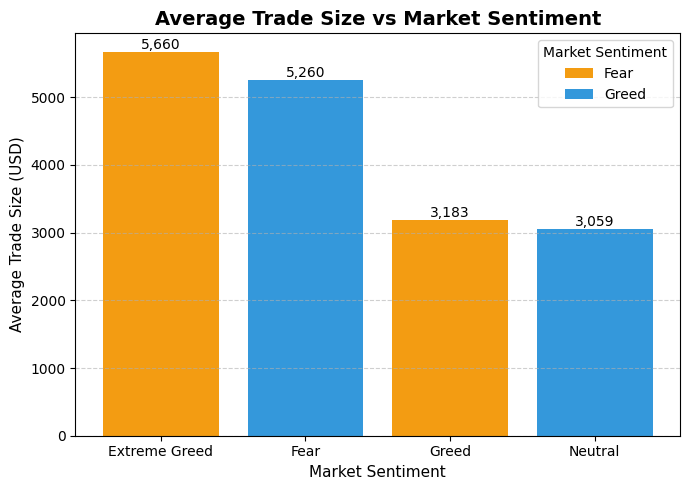

In [ ]:
## Analysis & Visualizations

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

size_by_sentiment = merged.groupby('classification')['size usd'].mean()
plt.figure(figsize=(7, 5))

bars = plt.bar(
    size_by_sentiment.index,
    size_by_sentiment.values,
    color=['#f39c12', '#3498db']
)
plt.title('Average Trade Size vs Market Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment', fontsize=11)
plt.ylabel('Average Trade Size (USD)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
legend_elements = [
    Patch(facecolor='#f39c12', label='Fear'),
    Patch(facecolor='#3498db', label='Greed')
]
plt.legend(handles=legend_elements, title='Market Sentiment')


plt.tight_layout()
plt.show()


In [ ]:
#The number of trades is higher during Greed periods compared to Fear periods, indicating increased market participation and confidence when sentiment is positive.


In [ ]:
merged['is_profitable'] = merged['closed pnl'] > 0


In [ ]:
win_rate = merged.groupby('classification')['is_profitable'].mean() * 100
win_rate


,is_profitable
classification,
Extreme Greed,49.008905
Fear,41.514592
Greed,44.647138
Neutral,31.718247


In [ ]:
#merged.groupby('classification')['closed pnl'].mean()
#merged.groupby('classification')['closed pnl'].median()

### Performance Metrics Summary

- **Average Profit:** Higher during Greed periods
- **Median Profit:** Confirms consistency of higher returns during Greed
- **Win Rate:** A larger proportion of profitable trades during Greed
- **Trade Count:** Increased trading activity during Greed


## Conclusion

This analysis demonstrates a clear relationship between market sentiment and trader behavior. Traders tend to achieve higher profitability, higher win rates, and place larger trades during Greed and Extreme Greed periods, indicating increased risk appetite and confidence. In contrast, Fear and Neutral market conditions are associated with more cautious trading behavior and lower overall performance.

These findings highlight the importance of market sentiment as a valuable signal in trading strategy design. Incorporating sentiment indicators alongside traditional metrics can help improve risk management and decision-making, especially in volatile market environments.
